# S4/S5 · AndinaLog 03B · Evidencia 2 · Vencimiento y merma

**Pregunta:** ¿Cómo se relacionan la permanencia en almacén y la cercanía al vencimiento con la merma, por categoría logística y centro de distribución?

Este notebook **solo lee** los Silver de Inventory Tracking y Productos. Construye y valida en memoria un dataset analítico con **una fila por lote/movimiento**, realiza el EDA y guía su interpretación. No corrige ni sobrescribe los Silver. Las relaciones observadas no demuestran causalidad.

`fecha_salida` vacía significa potencialmente que el lote continúa almacenado. Para esos lotes el análisis requiere una **fecha de corte**; no se inventa una fecha de salida.

## 1 · Configuración y carga

Ejecuta desde la raíz o una subcarpeta del proyecto. También puedes indicar las dos rutas absolutas en `RUTAS_MANUALES`. En Colab, ajusta `RUTA_PROYECTO_DRIVE`.

`FECHA_CORTE = None` usa la última fecha de ingreso o salida observada como **corte analítico inferido**. Para una evaluación operativa de stock vigente, establece una fecha de corte documentada que corresponda a una extracción real. `UMBRAL_RIESGO_DIAS` define el grupo «vence pronto» y es una decisión analítica configurable.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ENTORNO = "auto"  # auto, local o drive
RUTA_PROYECTO_DRIVE = "/content/drive/MyDrive/GIAD"
RUTAS_MANUALES = {"inventory": None, "productos": None}
FECHA_CORTE = None  # ejemplo: "2026-10-31"; None = última fecha operativa observada
UMBRAL_RIESGO_DIAS = 30
ARCHIVOS = {
    "inventory": "andinalog_inventory_tracking_silver.csv",
    "productos": "andinalog_productos_silver.csv",
}
SUBRUTAS = {
    "inventory": ["proyecto-integrador/andinalog_inventory_tracking/notebook2/salidas",
                  "S4/andinalog_inventory_tracking/notebook2/salidas"],
    "productos": ["proyecto-integrador/andinalog_productos/notebook2/salidas",
                  "S4/andinalog_productos/notebook2/salidas"],
}

def raices_posibles():
    entorno = ENTORNO
    if entorno == "auto":
        entorno = "drive" if "google.colab" in sys.modules else "local"
    if entorno == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        return [Path(RUTA_PROYECTO_DRIVE)]
    if entorno == "local":
        return [Path.cwd(), *Path.cwd().parents]
    raise ValueError("ENTORNO debe ser auto, local o drive")

def encontrar_silver(nombre):
    manual = RUTAS_MANUALES[nombre]
    if manual is not None:
        ruta = Path(manual)
        if not ruta.is_file():
            raise FileNotFoundError(f"No existe {nombre}: {ruta}")
        return ruta
    for raiz in raices_posibles():
        for subruta in SUBRUTAS[nombre]:
            ruta = raiz / subruta / ARCHIVOS[nombre]
            if ruta.is_file():
                return ruta
    raise FileNotFoundError(f"No se encontró {ARCHIVOS[nombre]}. Indica su ruta en RUTAS_MANUALES['{nombre}'].")

rutas = {nombre: encontrar_silver(nombre) for nombre in ARCHIVOS}
for nombre, ruta in rutas.items():
    print(nombre, "→", ruta)

def leer_silver(ruta):
    return pd.read_csv(ruta, dtype="string", encoding="utf-8-sig", keep_default_na=False)

inv_raw = leer_silver(rutas["inventory"])
productos_raw = leer_silver(rutas["productos"])

inventory → c:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_inventory_tracking\notebook2\salidas\andinalog_inventory_tracking_silver.csv
productos → c:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_productos\notebook2\salidas\andinalog_productos_silver.csv


## 2 · Contrato de entrada y validación de Silver

Inventory es una tabla de movimientos/lotes; Productos es una dimensión única por `producto_id`. El notebook detiene el análisis ante claves duplicadas, fechas imposibles o cantidades incompatibles. Permite `fecha_salida` vacía y contabiliza `fecha_vencimiento` faltante como riesgo **desconocido**.

In [2]:
REQ_INV = {"movimiento_id", "lote_id", "producto_id", "centro_distribucion", "fecha_ingreso",
           "fecha_salida", "fecha_vencimiento", "cantidad_ingreso", "cantidad_salida",
           "cantidad_merma", "dias_en_almacen"}
REQ_PROD = {"producto_id", "categoria_logistica"}
for nombre, tabla, req in [("Inventory", inv_raw, REQ_INV), ("Productos", productos_raw, REQ_PROD)]:
    faltantes = req - set(tabla.columns)
    if tabla.empty or faltantes:
        raise ValueError(f"{nombre}: vacío o faltan columnas {sorted(faltantes)}")
if inv_raw[["movimiento_id", "lote_id", "producto_id"]].eq("").any().any():
    raise ValueError("Inventory contiene claves vacías")
if inv_raw["movimiento_id"].duplicated().any() or inv_raw["lote_id"].duplicated().any():
    raise ValueError("Inventory no tiene una fila única por movimiento_id y lote_id")
if productos_raw["producto_id"].eq("").any() or productos_raw["producto_id"].duplicated().any():
    raise ValueError("Productos no es una dimensión única por producto_id")

inv = inv_raw.copy(deep=True)
productos = productos_raw.copy(deep=True)
for col in ["fecha_ingreso", "fecha_salida", "fecha_vencimiento"]:
    texto = inv[col].str.strip()
    fecha = pd.to_datetime(texto.replace("", pd.NA), format="%Y-%m-%d", errors="coerce")
    if (texto.ne("") & fecha.isna()).any():
        raise ValueError(f"Inventory contiene {col} con formato/valor inválido")
    inv[col] = fecha
for col in ["cantidad_ingreso", "cantidad_salida", "cantidad_merma", "dias_en_almacen"]:
    inv[col] = pd.to_numeric(inv[col], errors="raise")
if inv[["fecha_ingreso", "cantidad_ingreso", "cantidad_salida", "cantidad_merma", "dias_en_almacen"]].isna().any().any():
    raise ValueError("Inventory contiene fechas o medidas obligatorias nulas")
if inv["cantidad_ingreso"].le(0).any() or inv[["cantidad_salida", "cantidad_merma", "dias_en_almacen"]].lt(0).any().any():
    raise ValueError("Inventory contiene cantidades o días negativos, o ingreso no positivo")
if inv["cantidad_salida"].add(inv["cantidad_merma"]).gt(inv["cantidad_ingreso"]).any():
    raise ValueError("Salida + merma supera cantidad de ingreso")
if (inv["fecha_salida"].notna() & inv["fecha_salida"].lt(inv["fecha_ingreso"])).any():
    raise ValueError("Hay salidas anteriores al ingreso")

display(pd.DataFrame([
    {"fuente": "Inventory", "filas": len(inv), "columnas": len(inv.columns)},
    {"fuente": "Productos", "filas": len(productos), "columnas": len(productos.columns)},
]))
print("Lotes con salida vacía:", int(inv["fecha_salida"].isna().sum()))
print("Lotes con vencimiento faltante:", int(inv["fecha_vencimiento"].isna().sum()))

,fuente,filas,columnas
0,Inventory,5907,12
1,Productos,50,7


Lotes con salida vacía: 0
Lotes con vencimiento faltante: 0


## 3 · Granularidad, claves y cobertura previa

El join previsto es Inventory N:1 Productos por `producto_id`. Se muestra la cobertura antes de unir y se comprueba la coherencia de `dias_en_almacen` para lotes con salida. Una diferencia se informa; no se cambia el Silver ni se oculta.

In [3]:
sin_producto = ~inv["producto_id"].isin(productos["producto_id"])
con_salida = inv["fecha_salida"].notna()
dias_calculados_salida = (inv["fecha_salida"] - inv["fecha_ingreso"]).dt.days
discrepancia_dias = con_salida & dias_calculados_salida.ne(inv["dias_en_almacen"])
print("Movimientos sin correspondencia en Productos:", int(sin_producto.sum()))
print("Productos distintos sin correspondencia:", int(inv.loc[sin_producto, "producto_id"].nunique()))
print("Lotes salidos con días registrados distintos de fecha_salida - fecha_ingreso:", int(discrepancia_dias.sum()))
print("Una fila de Inventory = un lote/movimiento; una fila de Productos = un producto.")

Movimientos sin correspondencia en Productos: 1000
Productos distintos sin correspondencia: 10
Lotes salidos con días registrados distintos de fecha_salida - fecha_ingreso: 0
Una fila de Inventory = un lote/movimiento; una fila de Productos = un producto.


## 4 · Join y dataset analítico

Se conserva cada lote con un `left join`. `validate="many_to_one"` y las comprobaciones de filas/claves evitan multiplicar la merma. `aun_en_almacen` distingue una salida vacía de un dato erróneo.

Para calcular riesgo se usa `fecha_referencia`: la salida de un lote ya retirado o la fecha de corte para uno aún almacenado. Así, `dias_para_vencer` significa **margen al momento de referencia**, y se conserva el estado (`salido` o `aún almacenado`) en toda interpretación. Una merma histórica no se atribuye automáticamente al vencimiento.

In [4]:
analitico = inv.merge(
    productos[["producto_id", "categoria_logistica"]],
    on="producto_id", how="left", validate="many_to_one", indicator="match_producto"
)
if len(analitico) != len(inv) or analitico["lote_id"].duplicated().any():
    raise ValueError("El join alteró la granularidad por lote")

fechas_operativas = pd.concat([inv["fecha_ingreso"], inv["fecha_salida"].dropna()])
if FECHA_CORTE is None:
    fecha_corte = fechas_operativas.max().normalize()
    origen_corte = "inferida como última fecha operativa observada"
else:
    fecha_corte = pd.to_datetime(FECHA_CORTE, format="%Y-%m-%d", errors="raise").normalize()
    origen_corte = "indicada por el usuario"
if fecha_corte < fechas_operativas.max():
    raise ValueError("La fecha de corte precede a movimientos observados; limita primero el periodo analizado")

analitico["aun_en_almacen"] = analitico["fecha_salida"].isna()
analitico["fecha_referencia"] = analitico["fecha_salida"].fillna(fecha_corte)
analitico["dias_observados_hasta_referencia"] = (analitico["fecha_referencia"] - analitico["fecha_ingreso"]).dt.days
analitico["dias_para_vencer"] = (analitico["fecha_vencimiento"] - analitico["fecha_referencia"]).dt.days
analitico["vencido_a_referencia"] = analitico["dias_para_vencer"].lt(0) & analitico["dias_para_vencer"].notna()
analitico["vence_pronto_a_referencia"] = analitico["dias_para_vencer"].between(0, UMBRAL_RIESGO_DIAS)
analitico["estado_vencimiento"] = np.select(
    [analitico["dias_para_vencer"].isna(), analitico["vencido_a_referencia"],
     analitico["vence_pronto_a_referencia"]],
    ["Sin fecha de vencimiento", "Vencido", "Vence pronto"],
    default=f"Más de {UMBRAL_RIESGO_DIAS} días"
)
analitico["categoria_eda"] = analitico["categoria_logistica"].replace("", pd.NA).fillna("Sin correspondencia")
analitico["tasa_merma_pct"] = 100 * analitico["cantidad_merma"] / analitico["cantidad_ingreso"]
print("Fecha de corte:", fecha_corte.date(), "—", origen_corte)
print("Join:", len(inv), "lotes antes;", len(analitico), "después")
display(analitico["match_producto"].value_counts(dropna=False).rename("lotes").reset_index())

Fecha de corte: 2026-10-19 — inferida como última fecha operativa observada
Join: 5907 lotes antes; 5907 después


,match_producto,lotes
0,both,4907
1,left_only,1000
2,right_only,0


## 5 · Validación del dataset analítico

Las conciliaciones comprueban que el join no altera cantidades. Los lotes sin producto se mantienen como «Sin correspondencia» para hacer visible su cobertura. Se reportan casos con fecha de referencia anterior al ingreso, que requieren revisar el corte o los datos.

In [5]:
validacion = pd.DataFrame([
    {"control": "Lotes analíticos", "resultado": len(analitico)},
    {"control": "Claves lote duplicadas", "resultado": int(analitico["lote_id"].duplicated().sum())},
    {"control": "Lotes sin producto", "resultado": int(analitico["match_producto"].ne("both").sum())},
    {"control": "Lotes aún almacenados", "resultado": int(analitico["aun_en_almacen"].sum())},
    {"control": "Lotes sin fecha de vencimiento", "resultado": int(analitico["fecha_vencimiento"].isna().sum())},
    {"control": "Referencia anterior al ingreso", "resultado": int(analitico["dias_observados_hasta_referencia"].lt(0).sum())},
    {"control": "Merma total (unidades)", "resultado": float(analitico["cantidad_merma"].sum())},
])
display(validacion)
assert len(analitico) == len(inv)
assert analitico["cantidad_ingreso"].sum() == inv["cantidad_ingreso"].sum()
assert analitico["cantidad_merma"].sum() == inv["cantidad_merma"].sum()
assert analitico["dias_observados_hasta_referencia"].ge(0).all()
assert analitico["estado_vencimiento"].notna().all()

,control,resultado
0,Lotes analíticos,5907.0
1,Claves lote duplicadas,0.0
2,Lotes sin producto,1000.0
3,Lotes aún almacenados,0.0
4,Lotes sin fecha de vencimiento,0.0
5,Referencia anterior al ingreso,0.0
6,Merma total (unidades),52739.0


## 6 · Preguntas analíticas y EDA

1. ¿Cuántos lotes siguen almacenados y cuántos están vencidos o próximos a vencer a la fecha de corte?
2. ¿Cómo cambia el riesgo por categoría logística y centro de distribución?
3. ¿Cómo se distribuyen días en almacén y merma? ¿Hay grupos con mayor proporción de merma?
4. ¿Qué parte del resultado depende de lotes sin fecha de vencimiento o sin producto relacionado?

Se presentan conteos y denominadores. La **tasa global de merma** de un grupo se calcula como `sum(cantidad_merma) / sum(cantidad_ingreso)`, no como promedio simple de tasas por lote.

In [6]:
resumen_general = pd.DataFrame([{
    "lotes": len(analitico),
    "lotes_aun_en_almacen": int(analitico["aun_en_almacen"].sum()),
    "lotes_vencidos_a_referencia": int(analitico["vencido_a_referencia"].sum()),
    "lotes_vencen_pronto_a_referencia": int(analitico["vence_pronto_a_referencia"].sum()),
    "lotes_sin_fecha_vencimiento": int(analitico["dias_para_vencer"].isna().sum()),
    "merma_total_unidades": float(analitico["cantidad_merma"].sum()),
    "tasa_merma_global_pct": 100 * analitico["cantidad_merma"].sum() / analitico["cantidad_ingreso"].sum(),
    "dias_medianos_hasta_referencia": float(analitico["dias_observados_hasta_referencia"].median()),
}])
display(resumen_general.round(2))
display(analitico[["dias_en_almacen", "dias_observados_hasta_referencia", "dias_para_vencer",
                  "cantidad_merma", "tasa_merma_pct"]].describe(percentiles=[.25, .5, .75]).round(2))
display(analitico.groupby(["aun_en_almacen", "estado_vencimiento"], dropna=False).size().rename("lotes").reset_index())

,lotes,lotes_aun_en_almacen,lotes_vencidos_a_referencia,lotes_vencen_pronto_a_referencia,lotes_sin_fecha_vencimiento,merma_total_unidades,tasa_merma_global_pct,dias_medianos_hasta_referencia
0,5907,0,465,1495,0,52739.0,1.73,16.0


,dias_en_almacen,dias_observados_hasta_referencia,dias_para_vencer,cantidad_merma,tasa_merma_pct
count,5907.0,5907.00,5907.00,5907.0,5907.0
mean,17.19,17.19,200.41,8.93,1.72
std,9.65,9.65,152.21,9.15,1.32
min,1.0,1.00,-45.00,0.0,0.0
25%,10.0,10.00,11.00,3.0,0.68
50%,16.0,16.00,178.00,5.0,1.25
75%,23.0,23.00,346.00,12.0,2.64
max,69.0,69.00,357.00,81.0,10.29


,aun_en_almacen,estado_vencimiento,lotes
0,False,Más de 30 días,3947
1,False,Vence pronto,1495
2,False,Vencido,465


In [7]:
def resumir_grupo(columnas):
    tabla = analitico.groupby(columnas, dropna=False, as_index=False).agg(
        n_lotes=("lote_id", "size"),
        lotes_aun_en_almacen=("aun_en_almacen", "sum"),
        lotes_vencidos=("vencido_a_referencia", "sum"),
        lotes_vence_pronto=("vence_pronto_a_referencia", "sum"),
        lotes_sin_fecha_vencimiento=("fecha_vencimiento", lambda s: s.isna().sum()),
        cantidad_ingreso_total=("cantidad_ingreso", "sum"),
        merma_total=("cantidad_merma", "sum"),
        dias_promedio_hasta_referencia=("dias_observados_hasta_referencia", "mean"),
    )
    tabla["tasa_merma_pct"] = 100 * tabla["merma_total"] / tabla["cantidad_ingreso_total"]
    tabla["pct_lotes_vencidos"] = 100 * tabla["lotes_vencidos"] / tabla["n_lotes"]
    tabla["pct_lotes_vence_pronto"] = 100 * tabla["lotes_vence_pronto"] / tabla["n_lotes"]
    return tabla.sort_values("merma_total", ascending=False)

por_categoria = resumir_grupo(["categoria_eda"])
por_centro = resumir_grupo(["centro_distribucion"])
por_estado = resumir_grupo(["aun_en_almacen", "estado_vencimiento"])
print("Por categoría logística")
display(por_categoria.round(2))
print("Por centro de distribución")
display(por_centro.round(2))
print("Por estado de almacén y vencimiento")
display(por_estado.round(2))
assert por_categoria["n_lotes"].sum() == len(analitico)
assert por_centro["merma_total"].sum() == analitico["cantidad_merma"].sum()

Por categoría logística


,categoria_eda,n_lotes,lotes_aun_en_almacen,lotes_vencidos,lotes_vence_pronto,lotes_sin_fecha_vencimiento,cantidad_ingreso_total,merma_total,dias_promedio_hasta_referencia,tasa_merma_pct,pct_lotes_vencidos,pct_lotes_vence_pronto
1,Fresco,1564,0,371,1193,0,816082,26824,13.33,3.29,23.72,76.28
3,Sin correspondencia,1000,0,94,302,0,531137,9782,17.09,1.84,9.40,30.20
2,Seco,2416,0,0,0,0,1218125,9277,21.11,0.76,0.00,0.00
0,Congelado,927,0,0,0,0,481061,6856,13.59,1.43,0.00,0.00


Por centro de distribución


,centro_distribucion,n_lotes,lotes_aun_en_almacen,lotes_vencidos,lotes_vence_pronto,lotes_sin_fecha_vencimiento,cantidad_ingreso_total,merma_total,dias_promedio_hasta_referencia,tasa_merma_pct,pct_lotes_vencidos,pct_lotes_vence_pronto
2,Oruro,1214,0,97,315,0,627151,10984,17.22,1.75,7.99,25.95
0,Cochabamba,1217,0,95,289,0,626303,10764,17.28,1.72,7.81,23.75
1,La Paz,1167,0,82,316,0,593299,10418,16.92,1.76,7.03,27.08
4,Tarija,1173,0,90,303,0,601199,10298,16.86,1.71,7.67,25.83
3,Santa Cruz,1136,0,101,272,0,598453,10275,17.68,1.72,8.89,23.94


Por estado de almacén y vencimiento


,aun_en_almacen,estado_vencimiento,n_lotes,lotes_aun_en_almacen,lotes_vencidos,lotes_vence_pronto,lotes_sin_fecha_vencimiento,cantidad_ingreso_total,merma_total,dias_promedio_hasta_referencia,tasa_merma_pct,pct_lotes_vencidos,pct_lotes_vence_pronto
1,False,Vence pronto,1495,0,0,1495,0,780215,21926,9.38,2.81,0.0,100.0
0,False,Más de 30 días,3947,0,0,0,0,2016501,18857,19.12,0.94,0.0,0.0
2,False,Vencido,465,0,465,0,0,249689,11956,25.94,4.79,100.0,0.0


## 7 · Gráficos

La comparación por categoría incluye `n` para evitar conclusiones basadas en grupos pequeños. El gráfico de dispersión explora permanencia y tasa de merma por lote; no implica que permanecer más tiempo cause merma. Los lotes con y sin salida se distinguen.

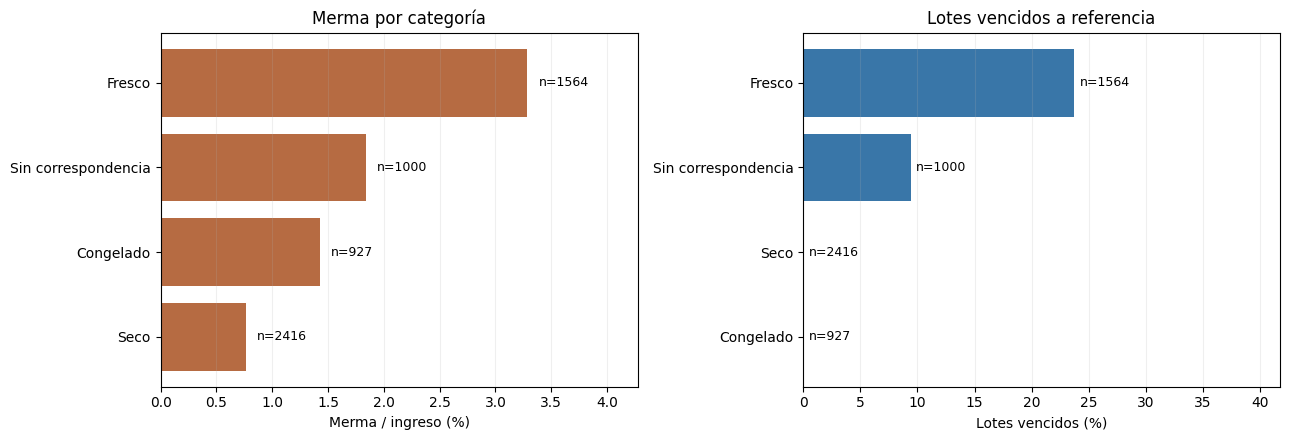

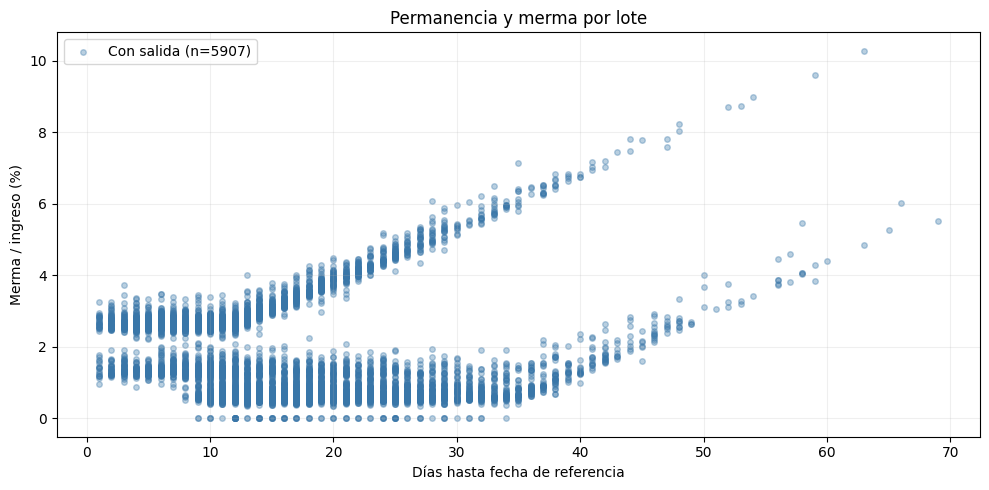

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
vista = por_categoria.sort_values("tasa_merma_pct")
axes[0].barh(vista["categoria_eda"].astype(str), vista["tasa_merma_pct"], color="#B66B42")
for y, (_, fila) in enumerate(vista.iterrows()):
    axes[0].text(fila["tasa_merma_pct"] + 0.1, y, f"n={int(fila['n_lotes'])}", va="center", fontsize=9)
axes[0].set_xlim(0, max(2, float(vista["tasa_merma_pct"].max()) * 1.3))
axes[0].set(title="Merma por categoría", xlabel="Merma / ingreso (%)")

vista2 = por_categoria.sort_values("pct_lotes_vencidos")
axes[1].barh(vista2["categoria_eda"].astype(str), vista2["pct_lotes_vencidos"], color="#3976A8")
for y, (_, fila) in enumerate(vista2.iterrows()):
    axes[1].text(fila["pct_lotes_vencidos"] + 0.5, y, f"n={int(fila['n_lotes'])}", va="center", fontsize=9)
axes[1].set_xlim(0, max(10, min(115, float(vista2["pct_lotes_vencidos"].max()) + 18)))
axes[1].set(title="Lotes vencidos a referencia", xlabel="Lotes vencidos (%)")
for ax in axes: ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for estado, grupo, color in [(False, "Con salida", "#3976A8"), (True, "Aún almacenado", "#B66B42")]:
    datos = analitico.loc[analitico["aun_en_almacen"].eq(estado)]
    if len(datos):
        ax.scatter(datos["dias_observados_hasta_referencia"], datos["tasa_merma_pct"],
                   s=16, alpha=.35, label=f"{grupo} (n={len(datos)})", color=color)
ax.set(title="Permanencia y merma por lote", xlabel="Días hasta fecha de referencia", ylabel="Merma / ingreso (%)")
ax.legend()
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()

## 8 · Interpretación y límites

Después de ejecutar, redacta al menos tres hallazgos. Para cada uno: **observación → cifra/gráfico → posible decisión operativa → límite**. Distingue siempre el riesgo de los lotes activos a la fecha de corte del estado observado al salir de los lotes cerrados.

- ¿Qué categorías o centros concentran lotes vencidos o próximos a vencer, y cuántos lotes sustentan el porcentaje?
- ¿La merma se concentra en pocos lotes o en grupos amplios? Usa cantidad y tasa con su denominador.
- ¿Cómo cambia la conclusión si se consideran únicamente lotes aún almacenados?
- ¿Cuántos lotes tienen riesgo desconocido por falta de vencimiento o producto?

**Limitaciones:** la fecha de corte inferida de los datos no equivale necesariamente a una foto operativa de inventario. `fecha_salida` vacía se interpreta como lote aún almacenado, sujeto a confirmar la semántica de origen. Una asociación entre permanencia, vencimiento y merma no demuestra su causa. Los Silver contienen solo filas utilizables; la cuarentena no está incluida.

In [9]:
print(f"ALCANCE: {len(analitico):,} lotes utilizables; {int(analitico['aun_en_almacen'].sum()):,} aún almacenados.")
print(f"CORTE: {fecha_corte.date()} ({origen_corte}); umbral de proximidad: {UMBRAL_RIESGO_DIAS} días.")
print(f"VENCIMIENTO: {int(analitico['vencido_a_referencia'].sum()):,} vencidos y "
      f"{int(analitico['vence_pronto_a_referencia'].sum()):,} próximos a vencer en su fecha de referencia; "
      f"{int(analitico['dias_para_vencer'].isna().sum()):,} sin fecha de vencimiento.")
print(f"MERMA: {analitico['cantidad_merma'].sum():,.0f} unidades, "
      f"{100*analitico['cantidad_merma'].sum()/analitico['cantidad_ingreso'].sum():.2f} % de lo ingresado.")
print(f"INTEGRIDAD: {int(analitico['match_producto'].ne('both').sum()):,} lotes sin producto; "
      f"{int(discrepancia_dias.sum()):,} diferencias entre días registrados y fechas para lotes salidos.")
print("Validaciones correctas. Los Silver no se modificaron.")

ALCANCE: 5,907 lotes utilizables; 0 aún almacenados.
CORTE: 2026-10-19 (inferida como última fecha operativa observada); umbral de proximidad: 30 días.
VENCIMIENTO: 465 vencidos y 1,495 próximos a vencer en su fecha de referencia; 0 sin fecha de vencimiento.
MERMA: 52,739 unidades, 1.73 % de lo ingresado.
INTEGRIDAD: 1,000 lotes sin producto; 0 diferencias entre días registrados y fechas para lotes salidos.
Validaciones correctas. Los Silver no se modificaron.
